In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('Iris.csv')

In [6]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df = df.iloc[:,1:]

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder = LabelEncoder()

In [12]:
df['Species'] = encoder.fit_transform(df['Species'])

In [13]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Converting to binary classification 

In [14]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [16]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

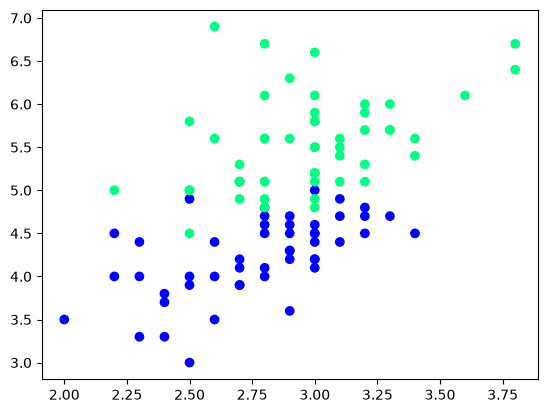

In [18]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [20]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
72,2.5,4.9,1
61,3.0,4.2,1
63,2.9,4.7,1
81,2.4,3.7,1
77,3.0,5.0,1
54,2.8,4.6,1
86,3.1,4.7,1
104,3.0,5.8,2
96,2.9,4.2,1
101,2.7,5.1,2


In [21]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [22]:
df_train

,SepalWidthCm,PetalLengthCm,Species
109,3.6,6.1,2
144,3.3,5.7,2
85,3.4,4.5,1
120,3.2,5.7,2
130,2.8,6.1,2
58,2.9,4.6,1
137,3.1,5.5,2
75,3.0,4.4,1
145,3.0,5.2,2
131,3.8,6.4,2


In [23]:
df_val

,SepalWidthCm,PetalLengthCm,Species
61,3.0,4.2,1
146,2.5,5.0,2
79,2.6,3.5,1
114,2.8,5.1,2
88,3.0,4.1,1


In [24]:
df_test

,SepalWidthCm,PetalLengthCm,Species
63,2.9,4.7,1
110,3.2,5.1,2
132,2.8,5.6,2
62,2.2,4.0,1
103,2.9,5.6,2


In [25]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [27]:
# y_test
X_test

array([[3. , 4.2],
       [2.5, 5. ],
       [2.6, 3.5],
       [2.8, 5.1],
       [3. , 4.1]])

# Case 1 - Bagging

In [28]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
58,2.9,4.6,1
137,3.1,5.5,2
137,3.1,5.5,2
58,2.9,4.6,1
145,3.0,5.2,2
144,3.3,5.7,2
75,3.0,4.4,1
137,3.1,5.5,2


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [30]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [31]:
dt_bag1 = DecisionTreeClassifier()

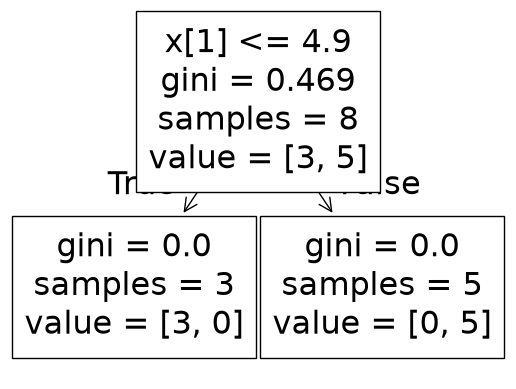

1.0


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


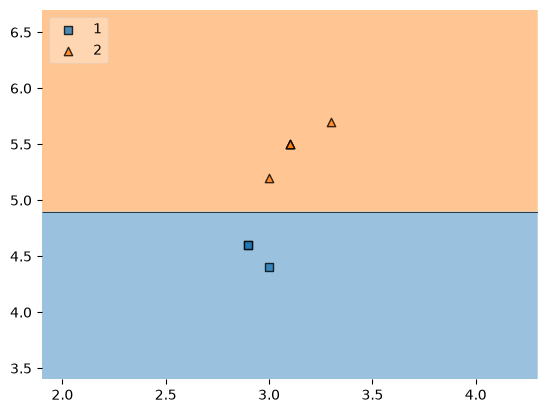

In [32]:
evaluate(dt_bag1,X,y)

In [ ]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
131,3.8,6.4,2
85,3.4,4.5,1
145,3.0,5.2,2
145,3.0,5.2,2
130,2.8,6.1,2
75,3.0,4.4,1
58,2.9,4.6,1
85,3.4,4.5,1


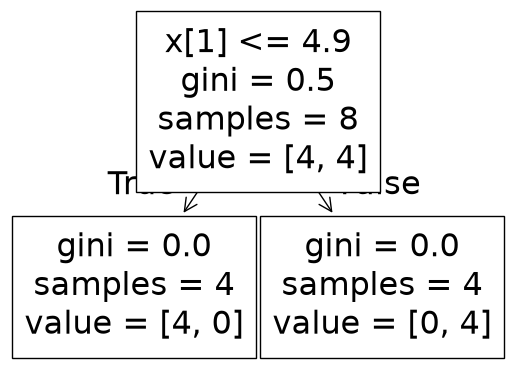

1.0


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


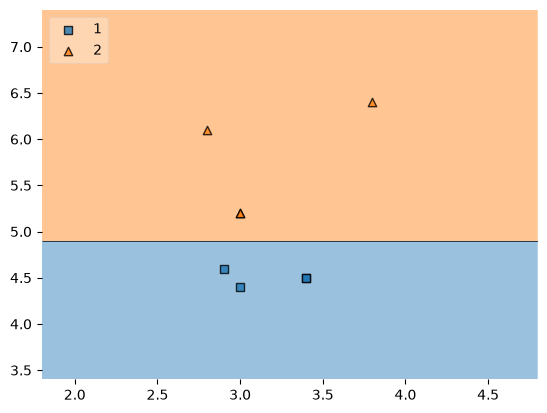

In [34]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [35]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
75,3.0,4.4,1
131,3.8,6.4,2
137,3.1,5.5,2
85,3.4,4.5,1
145,3.0,5.2,2
131,3.8,6.4,2
144,3.3,5.7,2
144,3.3,5.7,2


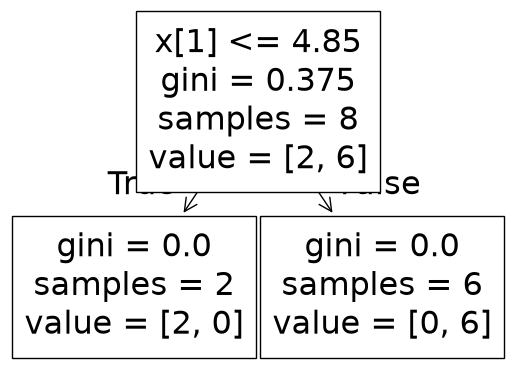

1.0


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


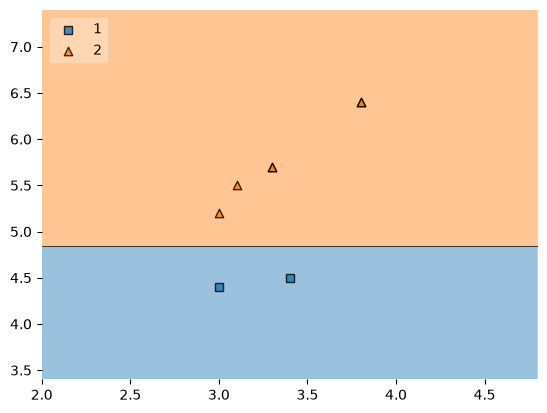

In [36]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [37]:
df_test

,SepalWidthCm,PetalLengthCm,Species
63,2.9,4.7,1
110,3.2,5.1,2
132,2.8,5.6,2
62,2.2,4.0,1
103,2.9,5.6,2


In [38]:
import numpy as np

In [40]:
print("Predictor 1",dt_bag1.predict(np.array([2.9,5.6]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.9,5.6]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.9,5.6]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

Row Sampling without replacement 

In [ ]:
# Pasting is Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
109,3.6,6.1,2
144,3.3,5.7,2
85,3.4,4.5,1
120,3.2,5.7,2
130,2.8,6.1,2
58,2.9,4.6,1
137,3.1,5.5,2
75,3.0,4.4,1
145,3.0,5.2,2
131,3.8,6.4,2


In [42]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
109,3.6,6.1,2
131,3.8,6.4,2
130,2.8,6.1,2
75,3.0,4.4,1
137,3.1,5.5,2
120,3.2,5.7,2
145,3.0,5.2,2
144,3.3,5.7,2


# Random Subspaces

We do column sampling  : we can do it with replacement or without replacement 

In [43]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [44]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
130,131,7.4,2.8,6.1,1.9,Iris-virginica
22,23,4.6,3.6,1.0,0.2,Iris-setosa
94,95,5.6,2.7,4.2,1.3,Iris-versicolor
146,147,6.3,2.5,5.0,1.9,Iris-virginica
133,134,6.3,2.8,5.1,1.5,Iris-virginica
138,139,6.0,3.0,4.8,1.8,Iris-virginica
127,128,6.1,3.0,4.9,1.8,Iris-virginica
30,31,4.8,3.1,1.6,0.2,Iris-setosa
132,133,6.4,2.8,5.6,2.2,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica


In [ ]:
df1.sample(2,replace=True,axis=1) # sampling 2 columns with replacement possible ie sometimes columns can repeat

,SepalLengthCm,SepalLengthCm
130,7.4,7.4
22,4.6,4.6
94,5.6,5.6
146,6.3,6.3
133,6.3,6.3
138,6.0,6.0
127,6.1,6.1
30,4.8,4.8
132,6.4,6.4
103,6.3,6.3


# Random Patches

We do both row and column sampling 

In [46]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
130,131,7.4,2.8,6.1,1.9,Iris-virginica
22,23,4.6,3.6,1.0,0.2,Iris-setosa
94,95,5.6,2.7,4.2,1.3,Iris-versicolor
146,147,6.3,2.5,5.0,1.9,Iris-virginica
133,134,6.3,2.8,5.1,1.5,Iris-virginica
138,139,6.0,3.0,4.8,1.8,Iris-virginica
127,128,6.1,3.0,4.9,1.8,Iris-virginica
30,31,4.8,3.1,1.6,0.2,Iris-setosa
132,133,6.4,2.8,5.6,2.2,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica


In [ ]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)  # chaining the row sampling with the column ie we get 8 rows and oly 2 columns of those rows 

,SepalLengthCm,SepalLengthCm
103,6.3,6.3
132,6.4,6.4
138,6.0,6.0
132,6.4,6.4
94,5.6,5.6
22,4.6,4.6
130,7.4,7.4
103,6.3,6.3


In [48]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)


,SepalLengthCm,Species
30,4.8,Iris-setosa
103,6.3,Iris-virginica
30,4.8,Iris-setosa
132,6.4,Iris-virginica
146,6.3,Iris-virginica
22,4.6,Iris-setosa
132,6.4,Iris-virginica
30,4.8,Iris-setosa
